# 07 - Modèle de prédiction des pertes économiques

## Objectif

L'objectif de ce modèle est de prédire les pertes économiques potentielles causées par un séisme.

Il s'agit d'un problème de **régression**, car la variable cible représente une valeur numérique.

## 1. Import des bibliothèques

Je commence par importer les bibliothèques nécessaires pour manipuler les données, effectuer les calculs, créer les graphiques et entraîner les modèles de régression.

In [8]:
# ============================================================
# MODÈLE 7 — PERTES ÉCONOMIQUES
# Prédiction des pertes économiques
# ============================================================

import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

print("Bibliothèques chargées avec succès.")

Bibliothèques chargées avec succès.


**Interprétation du résultat :**

Le chargement s'est bien passé. Les bibliothèques nécessaires sont maintenant prêtes pour la suite du notebook.

In [10]:
# Charger le dataset

file_path = os.path.join("..", "data", "usgs_earthquakes_2025.csv")

df = pd.read_csv(file_path)

print("Fichier chargé avec succès.")
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

df.head()

Fichier chargé avec succès.
Nombre de lignes : 29062
Nombre de colonnes : 35


,mag,place,time,updated,tz,url,detail,felt,cdi,mmi,alert,status,tsunami,sig,net,code,ids,sources,types,nst,dmin,rms,gap,magType,type,title,longitude,latitude,depth,event_id,date_time,year,month,day,hour
0,4.2,"70 km W of Abra Pampa, Argentina",1751241591065,1757018402040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,271,us,7000q9mu,",us7000q9mu,",",us,",",origin,phase-data,",19.0,1.696,0.70,89.0,mb,earthquake,"M 4.2 - 70 km W of Abra Pampa, Argentina",-66.3753,-22.6251,247.528,us7000q9mu,2025-06-29 23:59:51.065000+00:00,2025,6,29,23
1,2.5,"1 km E of Nikolski, Alaska",1751241495097,1757018405040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,96,us,7000qb5r,",ak0258a2rwky,us7000qb5r,",",ak,us,",",origin,phase-data,",17.0,0.035,0.42,198.0,ml,earthquake,"M 2.5 - 1 km E of Nikolski, Alaska",-168.8412,52.9376,61.149,us7000qb5r,2025-06-29 23:58:15.097000+00:00,2025,6,29,23
2,2.8,"31 km SSE of Nikolski, Alaska",1751241219318,1757018405040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,121,us,7000qb5v,",ak0258a2qvpj,us7000qb5v,",",ak,us,",",origin,phase-data,",10.0,0.316,0.51,231.0,ml,earthquake,"M 2.8 - 31 km SSE of Nikolski, Alaska",-168.6544,52.6804,35.000,us7000qb5v,2025-06-29 23:53:39.318000+00:00,2025,6,29,23
3,3.8,"153 km S of Nikolski, Alaska",1751241150341,1757018402040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,222,us,7000q9mt,",ak0258a2qnbw,us7000q9mt,",",ak,us,",",origin,phase-data,",55.0,1.411,0.42,185.0,mb,earthquake,"M 3.8 - 153 km S of Nikolski, Alaska",-168.5438,51.5761,10.000,us7000q9mt,2025-06-29 23:52:30.341000+00:00,2025,6,29,23
4,4.5,"185 km WSW of Tual, Indonesia",1751240317514,1757018402040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,312,us,7000q9mq,",us7000q9mq,",",us,",",origin,phase-data,",31.0,3.637,0.48,93.0,mb,earthquake,"M 4.5 - 185 km WSW of Tual, Indonesia",131.2977,-6.4544,35.000,us7000q9mq,2025-06-29 23:38:37.514000+00:00,2025,6,29,23


**Interprétation du résultat :**

Le fichier a été chargé correctement. Il contient **29 062 séismes** et **35 variables**. Les premières lignes permettent de vérifier la structure des données avant de commencer l'analyse.

## 3. Exploration des données

Je vérifie maintenant la structure du dataset, les types de variables et les valeurs manquantes avant de préparer les données pour le modèle.

In [13]:
# Informations générales sur le dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29062 entries, 0 to 29061
Data columns (total 35 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   mag        29062 non-null  float64
 1   place      29062 non-null  object 
 2   time       29062 non-null  int64  
 3   updated    29062 non-null  int64  
 4   tz         0 non-null      float64
 5   url        29062 non-null  object 
 6   detail     29062 non-null  object 
 7   felt       3877 non-null   float64
 8   cdi        3877 non-null   float64
 9   mmi        1990 non-null   float64
 10  alert      904 non-null    object 
 11  status     29062 non-null  object 
 12  tsunami    29062 non-null  int64  
 13  sig        29062 non-null  int64  
 14  net        29062 non-null  object 
 15  code       29062 non-null  object 
 16  ids        29062 non-null  object 
 17  sources    29062 non-null  object 
 18  types      29062 non-null  object 
 19  nst        27765 non-null  float64
 20  dmin  

**Interprétation du résultat :**

Le dataset contient **29 062 observations** et **35 variables**.

Certaines variables sont complètes, comme `mag`, `depth`, `sig`, `latitude` et `longitude`.

D'autres variables contiennent beaucoup de valeurs manquantes, notamment `tz`, `alert`, `mmi`, `cdi` et `felt`. Ces variables devront être examinées avant de construire le modèle.

## 4. Vérification des valeurs manquantes

Je vérifie les valeurs manquantes afin d'identifier les variables qui nécessitent un prétraitement.

In [16]:
# Calculer le nombre de valeurs manquantes par variable

df.isnull().sum().sort_values(ascending=False)

tz           29062
alert        28158
mmi          27072
felt         25185
cdi          25185
dmin          1305
gap           1302
nst           1297
time             0
mag              0
place            0
status           0
tsunami          0
sig              0
net              0
code             0
detail           0
updated          0
url              0
types            0
sources          0
ids              0
rms              0
magType          0
type             0
title            0
longitude        0
latitude         0
depth            0
event_id         0
date_time        0
year             0
month            0
day              0
hour             0
dtype: int64

**Interprétation du résultat :**

La variable `tz` est entièrement vide.

Les variables `alert`, `mmi`, `felt` et `cdi` contiennent également beaucoup de valeurs manquantes.

Les variables `dmin`, `gap` et `nst` contiennent quelques valeurs manquantes.

Les principales variables comme `mag`, `depth`, `sig`, `latitude`, `longitude` et `tsunami` sont complètes.

## 5. Statistiques descriptives

Je consulte les statistiques descriptives des principales variables numériques afin de mieux comprendre les données avant le prétraitement.

In [18]:
# Statistiques descriptives des principales variables numériques

df[['mag', 'depth', 'sig', 'latitude', 'longitude', 'tsunami']].describe()

,mag,depth,sig,latitude,longitude,tsunami
count,29062.000000,29062.000000,29062.000000,29062.000000,29062.000000,29062.000000
mean,3.932225,56.666893,251.693104,25.276752,-5.452179,0.004852
std,0.844800,103.944863,110.083046,31.354716,133.979064,0.069486
min,2.500000,-3.420000,96.000000,-73.220400,-179.994400,0.000000
25%,3.100000,10.000000,148.000000,2.070675,-139.941275,0.000000
50%,4.200000,15.490000,271.000000,36.019750,-61.226250,0.000000
75%,4.500000,53.800000,312.000000,51.869925,142.128075,0.000000
max,8.800000,669.556000,2910.000000,87.081500,179.999400,1.000000


**Interprétation du résultat :**

La magnitude moyenne des séismes est d'environ **3,93**, avec un maximum de **8,8**.

La profondeur moyenne est d'environ **56,67 km**, mais certains séismes atteignent plus de **669 km** de profondeur.

La variable `sig`, qui représente l'importance d'un événement selon l'USGS, varie fortement et atteint un maximum de **2910**.

La variable `tsunami` est presque toujours égale à 0, ce qui indique que très peu de séismes du dataset sont associés à un tsunami.

## 6. Distribution de la magnitude

Je visualise la distribution de la magnitude afin de voir comment les séismes sont répartis selon leur intensité.

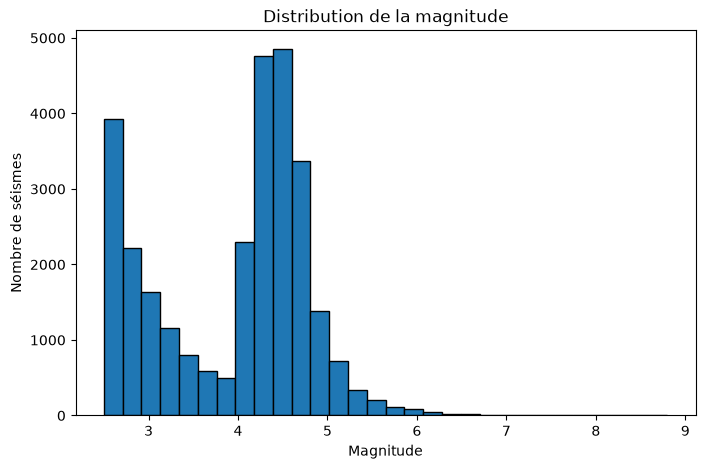

In [19]:
# Visualiser la distribution de la magnitude

plt.figure(figsize=(8, 5))

plt.hist(df['mag'], bins=30, edgecolor='black')

plt.title("Distribution de la magnitude")
plt.xlabel("Magnitude")
plt.ylabel("Nombre de séismes")

plt.show()

**Interprétation du résultat :**

La majorité des séismes ont une magnitude comprise entre **2,5 et 5**.

Les séismes de forte magnitude sont beaucoup plus rares.

Quelques événements dépassent une magnitude de **6**, avec un maximum de **8,8** dans le dataset.

## 7. Distribution de la profondeur

Je visualise la distribution de la profondeur afin d'observer à quelles profondeurs se produisent principalement les séismes du dataset.

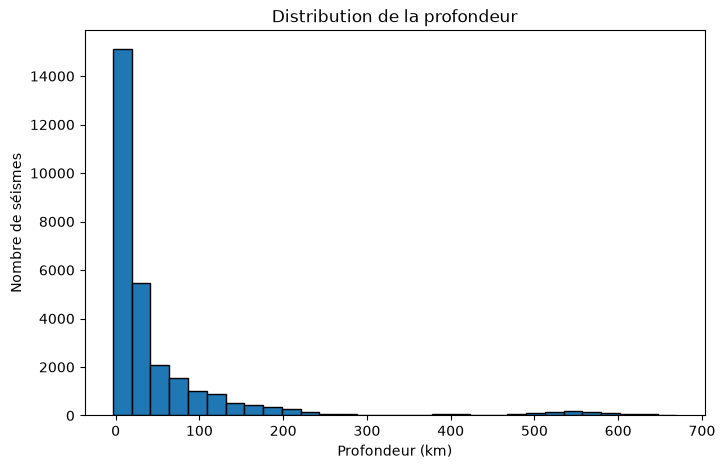

In [22]:
# Visualiser la distribution de la profondeur

plt.figure(figsize=(8, 5))

plt.hist(df['depth'], bins=30, edgecolor='black')

plt.title("Distribution de la profondeur")
plt.xlabel("Profondeur (km)")
plt.ylabel("Nombre de séismes")

plt.show()

**Interprétation du résultat :**

La majorité des séismes se produisent à faible profondeur, principalement sous **100 km**.

Le nombre de séismes diminue fortement lorsque la profondeur augmente.

Quelques séismes très profonds apparaissent entre **500 et 650 km**.

## 8. Relation entre la magnitude et l'importance du séisme

Je vérifie la relation entre la magnitude (`mag`) et l'indice d'importance (`sig`) afin de voir si les séismes plus puissants sont généralement associés à une importance plus élevée.

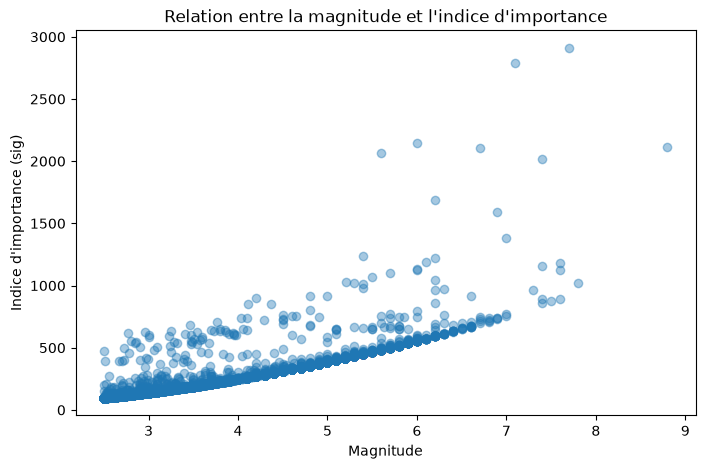

In [24]:
# Relation entre la magnitude et l'indice d'importance

plt.figure(figsize=(8, 5))

plt.scatter(df['mag'], df['sig'], alpha=0.4)

plt.title("Relation entre la magnitude et l'indice d'importance")
plt.xlabel("Magnitude")
plt.ylabel("Indice d'importance (sig)")

plt.show()

**Interprétation du résultat :**

Le graphique montre une relation positive entre la magnitude et l'indice `sig`.

En général, plus la magnitude augmente, plus l'importance du séisme augmente.

Certains événements présentent toutefois un indice `sig` beaucoup plus élevé que les autres, ce qui montre que la magnitude n'est pas le seul facteur associé à l'importance d'un séisme.

## 9. Corrélation entre les variables principales

Je calcule la corrélation entre les principales variables numériques afin d'identifier les relations qui peuvent être utiles pour le modèle.

In [27]:
# Calculer la matrice de corrélation

variables = ['mag', 'depth', 'sig', 'latitude', 'longitude', 'tsunami']

correlation = df[variables].corr()

correlation

,mag,depth,sig,latitude,longitude,tsunami
mag,1.000000,0.138449,0.927889,-0.471871,0.615148,0.123800
depth,0.138449,1.000000,0.101972,-0.298971,-0.020736,-0.011504
sig,0.927889,0.101972,1.000000,-0.411836,0.532706,0.203798
latitude,-0.471871,-0.298971,-0.411836,1.000000,-0.132575,0.026554
longitude,0.615148,-0.020736,0.532706,-0.132575,1.000000,-0.032618
tsunami,0.123800,-0.011504,0.203798,0.026554,-0.032618,1.000000


**Interprétation du résultat :**

La magnitude (`mag`) et l'indice d'importance (`sig`) présentent une très forte corrélation positive de **0,93**.

La magnitude présente également une corrélation positive avec la longitude (**0,62**) dans ce dataset.

La profondeur a des corrélations relativement faibles avec les autres variables.

Ces résultats permettent de mieux comprendre les relations entre les variables avant de construire le modèle de prédiction.

## 10. Définition de la variable cible

Le dataset USGS ne contient pas directement une variable représentant les pertes économiques en dollars.

Avant d'entraîner un modèle de régression, je dois donc définir une variable cible (`Y`) représentant les pertes économiques à partir d'une source de données appropriée, plutôt que d'inventer artificiellement des valeurs de pertes.

In [30]:
# Rechercher une variable pouvant représenter les pertes économiques

keywords = ['loss', 'damage', 'cost', 'economic', 'money']

economic_columns = [
    col for col in df.columns
    if any(word in col.lower() for word in keywords)
]

print("Variables économiques trouvées :", economic_columns)

Variables économiques trouvées : []


**Interprétation du résultat :**

Aucune variable représentant directement les pertes économiques n'est disponible dans le dataset USGS.

Pour construire un modèle supervisé de prédiction des pertes économiques, il est nécessaire d'obtenir ou de construire une variable cible `Y` à partir de données réelles sur les pertes économiques associées aux séismes.

Il ne serait pas approprié d'inventer des montants en dollars à partir de la magnitude, car le modèle apprendrait simplement la formule utilisée pour créer la cible.

## 12. Source de la variable cible

Pour entraîner le modèle, la variable cible `Y` doit représenter une perte économique réelle.

Les données USGS seront donc utilisées pour les caractéristiques du séisme (`X`), tandis qu'une source externe de pertes économiques sera utilisée pour obtenir la cible (`Y`).

Les deux jeux de données pourront ensuite être associés aux événements correspondants.

## 13. Sélection des variables explicatives

Je sélectionne les caractéristiques du séisme qui pourront être utilisées comme variables explicatives (`X`) pour prédire les pertes économiques.

In [33]:
# Sélection des variables explicatives

features = [
    'mag',
    'depth',
    'sig',
    'latitude',
    'longitude',
    'tsunami'
]

X = df[features].copy()

X.head()

,mag,depth,sig,latitude,longitude,tsunami
0,4.2,247.528,271,-22.6251,-66.3753,0
1,2.5,61.149,96,52.9376,-168.8412,0
2,2.8,35.000,121,52.6804,-168.6544,0
3,3.8,10.000,222,51.5761,-168.5438,0
4,4.5,35.000,312,-6.4544,131.2977,0


**Interprétation du résultat :**

Les variables explicatives `X` contiennent **6 caractéristiques** du séisme : la magnitude, la profondeur, l'indice d'importance, la latitude, la longitude et l'indicateur de tsunami.

Ces variables sont complètes et pourront être utilisées comme entrées du modèle de prédiction.

## 14. Conservation de l'identifiant des événements

Je conserve l'identifiant unique `event_id` de chaque séisme.

Cet identifiant permettra d'associer les données USGS aux données réelles de pertes économiques provenant d'une autre source.

In [36]:
# Conserver l'identifiant unique de chaque séisme

event_ids = df['event_id'].copy()

event_ids.head()

0    us7000q9mu
1    us7000qb5r
2    us7000qb5v
3    us7000q9mt
4    us7000q9mq
Name: event_id, dtype: object

**Interprétation du résultat :**

Chaque séisme possède un identifiant unique `event_id`, par exemple `us7000q9mu`.

Cet identifiant sera utilisé pour associer chaque événement USGS à une éventuelle donnée de perte économique, mais il ne sera pas utilisé comme variable d'entrée du modèle.

## 15. Vérification des variables explicatives

Je vérifie les dimensions de `X` afin de confirmer que toutes les observations ont été conservées après la sélection des variables.

In [39]:
# Vérifier les dimensions de X

print("Nombre de lignes :", X.shape[0])
print("Nombre de variables :", X.shape[1])

Nombre de lignes : 29062
Nombre de variables : 6


**Interprétation du résultat :**

La matrice `X` contient **29 062 observations** et **6 variables explicatives**.

Aucune observation n'a été perdue lors de la sélection des variables.

## 16. Vérification des valeurs manquantes dans X

Je vérifie que les variables sélectionnées pour le modèle ne contiennent aucune valeur manquante.

In [42]:
# Vérifier les valeurs manquantes dans X

X.isnull().sum()

mag          0
depth        0
sig          0
latitude     0
longitude    0
tsunami      0
dtype: int64

**Interprétation du résultat :**

Les six variables sélectionnées ne contiennent aucune valeur manquante.

Les données explicatives `X` sont donc complètes et ne nécessitent pas de traitement des valeurs manquantes.

## 17. Préparation de la variable cible Y

La matrice `X` est maintenant prête.

La prochaine étape consiste à obtenir la variable cible `Y`, représentant les pertes économiques réelles associées aux séismes.

Cette variable devra être associée aux événements USGS avant de diviser les données en ensembles d'entraînement et de test.

## 18. Données économiques USGS PAGER

Pour obtenir la variable cible `Y`, j'utilise les données **USGS PAGER**.

PAGER fournit des estimations des pertes économiques associées aux séismes significatifs.

Ces informations permettront de construire une cible économique basée sur des estimations USGS plutôt que sur des valeurs inventées.

## 19. Vérification des données PAGER

Avant de récupérer les pertes économiques pour l'ensemble du dataset, je vérifie la disponibilité des données PAGER pour un événement USGS.

Cette étape permet de comprendre la structure des données économiques avant de les intégrer au dataset.

In [48]:
# Sélectionner le séisme de plus forte magnitude du dataset

event_test = df.loc[df['mag'].idxmax()]

print("Event ID :", event_test['event_id'])
print("Magnitude :", event_test['mag'])
print("Lieu :", event_test['place'])
print("Date :", event_test['date_time'])

Event ID : us6000qw60
Magnitude : 8.8
Lieu : 2025 Kamchatka Peninsula, Russia Earthquake
Date : 2025-07-29 23:24:52.483000+00:00


**Interprétation du résultat :**

Le séisme sélectionné possède une magnitude de **8,8** et s'est produit dans la péninsule du Kamchatka en Russie.

Comme il s'agit du séisme de plus forte magnitude du dataset, cet événement constitue un bon candidat pour vérifier la disponibilité des estimations de pertes économiques PAGER.

In [50]:
# Récupérer les détails USGS de l'événement test

import requests

event_id = "us6000qw60"

url = f"https://earthquake.usgs.gov/fdsnws/event/1/query?eventid={event_id}&format=geojson"

response = requests.get(url)

print("Code HTTP :", response.status_code)

event_data = response.json()

print("Données récupérées avec succès.")

Code HTTP : 200
Données récupérées avec succès.


**Interprétation du résultat :**

Le code HTTP **200** confirme que la requête vers le service USGS a réussi.

Les informations détaillées du séisme sont maintenant disponibles dans `event_data`. La prochaine étape consiste à vérifier si cet événement contient un produit **PAGER** avec des informations sur les pertes économiques.

In [52]:
# Afficher les produits disponibles pour cet événement

products = event_data.get("properties", {}).get("products", {})

print("Produits disponibles :")
print(list(products.keys()))

Produits disponibles :
['dyfi', 'earthquake-name', 'event-sequence', 'finite-fault', 'general-link', 'general-text', 'ground-failure', 'impact-link', 'impact-text', 'internal-moment-tensor', 'internal-origin', 'losspager', 'moment-tensor', 'oaf', 'origin', 'phase-data', 'shakemap']


**Interprétation du résultat :**

L'événement possède un produit `losspager`.

Ce produit contient les estimations PAGER liées aux conséquences du séisme, notamment les estimations de pertes économiques.

Nous pouvons donc utiliser `losspager` pour rechercher la variable cible `Y`.

In [54]:
# Récupérer le produit LossPAGER

losspager = products['losspager'][0]

# Afficher les fichiers disponibles dans LossPAGER

contents = losspager.get('contents', {})

print("Fichiers disponibles dans LossPAGER :")

for filename in contents.keys():
    print(filename)

Fichiers disponibles dans LossPAGER :
json/cities.json
onepager.pdf
alertecon.png
json/comments.json
exposure.png
alertfatal_small.png
json/alerts.json
json/exposures.json
json/historical_earthquakes.json
alertecon.pdf
grid.xml
onepager.aux
contents.xml
exposure.pdf
json/losses.json
alertfatal.pdf
alertfatal_smaller.png
json/event.json
onepager.tex
pager.xml
alertecon_small.png
alertecon_smaller.png
alertfatal.png


**Interprétation du résultat :**

Le produit `losspager` contient plusieurs fichiers.

Le fichier `json/losses.json` est particulièrement important pour notre modèle, car il contient les informations relatives aux estimations de pertes.

Je vais maintenant examiner son contenu afin d'identifier la valeur qui pourra servir de variable cible `Y`.

In [55]:
# Récupérer l'URL du fichier losses.json

losses_url = contents['json/losses.json']['url']

# Télécharger les données de pertes
losses_response = requests.get(losses_url)

print("Code HTTP :", losses_response.status_code)

losses_data = losses_response.json()

print("Données de pertes récupérées avec succès.")

Code HTTP : 200
Données de pertes récupérées avec succès.


**Interprétation du résultat :**

Le code HTTP **200** confirme que le fichier `losses.json` a été téléchargé correctement.

Les données PAGER relatives aux pertes sont maintenant disponibles dans la variable `losses_data`.

La prochaine étape consiste à examiner leur structure afin d'identifier précisément les estimations de pertes économiques.

In [56]:
# Examiner la structure des données de pertes

print("Clés disponibles dans losses.json :")

print(losses_data.keys())

Clés disponibles dans losses.json :
dict_keys(['empirical_fatality', 'empirical_economic', 'semi_empirical_fatalities'])


**Interprétation du résultat :**

Le fichier `losses.json` contient trois catégories de résultats.

La section `empirical_economic` contient les estimations des pertes économiques.

Cette section sera examinée pour déterminer la variable cible `Y` de notre modèle de régression.

In [58]:
# Examiner les données de pertes économiques

economic_data = losses_data['empirical_economic']

print("Type :", type(economic_data))

economic_data

Type : <class 'dict'>


{'total_dollars': 10238972670,
 'country_dollars': [{'country_code': 'RU',
   'rates': [2.0991953314921798e-91,
    2.5310497412664658e-42,
    1.7017430886602766e-22,
    2.196519097843858e-12,
    8.754773553956376e-07,
    0.0012280277383668343,
    0.06083405411828719,
    0.39550427673667554,
    0.8068964192106685,
    0.9698567834013938],
   'us_dollars': 10238972670}]}

**Interprétation du résultat :**

La section `empirical_economic` contient une variable `total_dollars`.

Pour le séisme testé, la perte économique estimée par PAGER est de **10 238 972 670 $**, soit environ **10,24 milliards de dollars**.

Cette variable peut servir de variable cible `Y` pour le modèle de régression des pertes économiques.

Les données `country_dollars` fournissent également une répartition des pertes estimées par pays.

In [59]:
# Extraire la perte économique totale estimée

economic_loss = economic_data['total_dollars']

print("Perte économique estimée :", economic_loss, "$")
print("Perte économique estimée en milliards :", round(economic_loss / 1_000_000_000, 2), "milliards $")

Perte économique estimée : 10238972670 $
Perte économique estimée en milliards : 10.24 milliards $


**Interprétation du résultat :**

La perte économique estimée pour cet événement est de **10 238 972 670 $**, soit environ **10,24 milliards de dollars**.

L'extraction de `total_dollars` fonctionne correctement. Cette valeur pourra donc être utilisée comme variable cible `Y`.

La prochaine étape sera d'automatiser cette extraction pour les événements du dataset qui possèdent des données `losspager`.

## 28. Automatisation de la récupération des pertes économiques

Je crée une fonction qui utilise l'identifiant `event_id` d'un séisme pour rechercher automatiquement les données `losspager` et récupérer la perte économique estimée par PAGER.

Si aucune estimation économique n'est disponible pour un événement, la fonction retournera une valeur manquante.

In [60]:
# Fonction pour récupérer la perte économique PAGER

def get_economic_loss(event_id):
    try:
        # Requête vers les détails de l'événement USGS
        url = f"https://earthquake.usgs.gov/fdsnws/event/1/query?eventid={event_id}&format=geojson"
        response = requests.get(url, timeout=15)

        if response.status_code != 200:
            return np.nan

        event_data = response.json()

        # Vérifier si le produit losspager existe
        products = event_data.get("properties", {}).get("products", {})

        if "losspager" not in products:
            return np.nan

        # Récupérer le produit LossPAGER
        losspager = products["losspager"][0]
        contents = losspager.get("contents", {})

        if "json/losses.json" not in contents:
            return np.nan

        # Télécharger losses.json
        losses_url = contents["json/losses.json"]["url"]
        losses_response = requests.get(losses_url, timeout=15)

        if losses_response.status_code != 200:
            return np.nan

        losses_data = losses_response.json()

        # Extraire la perte économique
        economic_data = losses_data.get("empirical_economic", {})

        return economic_data.get("total_dollars", np.nan)

    except Exception:
        return np.nan

In [61]:
# Tester la fonction sur l'événement déjà utilisé

test_loss = get_economic_loss("us6000qw60")

print("Perte économique récupérée :", test_loss, "$")

Perte économique récupérée : 10238972670 $


**Interprétation du résultat :**

La fonction retourne correctement une perte économique estimée de **10 238 972 670 $** pour l'événement testé.

Le résultat est identique à celui obtenu lors de l'extraction manuelle.

La fonction peut donc être utilisée pour récupérer automatiquement les pertes économiques PAGER des autres séismes.

## 30. Sélection des séismes significatifs

Les données PAGER ne sont pas disponibles pour tous les séismes.

Afin d'éviter des milliers de requêtes inutiles, je sélectionne d'abord les événements ayant une magnitude supérieure ou égale à **5,0**.

Ces événements seront utilisés pour rechercher les estimations de pertes économiques PAGER.

In [63]:
# Sélectionner les séismes de magnitude >= 5.0

df_significant = df[df['mag'] >= 5.0].copy()

print("Nombre total de séismes :", len(df))
print("Nombre de séismes de magnitude >= 5.0 :", len(df_significant))

Nombre total de séismes : 29062
Nombre de séismes de magnitude >= 5.0 : 2122


**Interprétation du résultat :**

Le dataset contient **29 062 séismes** au total.

Parmi eux, **2 122 séismes** ont une magnitude supérieure ou égale à **5,0**.

Cette sélection réduit fortement le nombre de requêtes à effectuer et permet de concentrer la recherche PAGER sur les événements les plus significatifs.

## 31. Test de récupération sur un échantillon

Avant d'appliquer la fonction à tous les séismes sélectionnés, je la teste sur un petit échantillon de **10 événements**.

Cette étape permet de vérifier que la récupération automatique fonctionne correctement.

In [65]:
# Tester la récupération sur 10 séismes

sample_events = df_significant.head(10).copy()

sample_events['economic_loss'] = sample_events['event_id'].apply(get_economic_loss)

sample_events[['event_id', 'mag', 'place', 'economic_loss']]

,event_id,mag,place,economic_loss
47,us7000q9hh,5.2,"103 km N of Tatsugō, Japan",NaN
50,us7000q9hc,5.3,"162 km SSW of Lorengau, Papua New Guinea",NaN
54,us7000q9h4,5.1,south of Panama,NaN
72,us7000q9fs,5.4,"98 km NNW of Tatsugō, Japan",0.0
80,us7000q9f3,5.2,"56 km NNE of Barkhan, Pakistan",68378.0
86,us7000q9e7,5.0,"24 km SSW of Puerto San José, Guatemala",NaN
92,us7000q9dv,5.2,South Sandwich Islands region,NaN
108,us7000q9d1,5.3,"136 km NNW of Tobelo, Indonesia",NaN
117,us7000q9cb,5.1,"288 km NW of Chokurdakh, Russia",NaN
123,us7000q9b5,6.6,Scotia Sea,0.0


**Interprétation du résultat :**

Le test montre que les données PAGER ne sont pas disponibles pour tous les séismes de magnitude supérieure ou égale à **5,0**.

Une valeur `NaN` indique qu'aucune estimation économique exploitable n'a été trouvée pour l'événement.

Une valeur `0.0` indique qu'une estimation PAGER existe, mais que la perte économique estimée est nulle.

Certaines observations possèdent une perte économique positive, par exemple **68 378 $**.

Il est donc important de conserver la différence entre une valeur manquante (`NaN`) et une perte estimée à zéro.

In [66]:
# Compter les données économiques disponibles

available = sample_events['economic_loss'].notna().sum()
missing = sample_events['economic_loss'].isna().sum()

print("Pertes économiques disponibles :", available)
print("Pertes économiques manquantes :", missing)

Pertes économiques disponibles : 3
Pertes économiques manquantes : 7


**Interprétation du résultat :**

Sur les **10 séismes** testés, **3 événements** possèdent une estimation de perte économique PAGER et **7 événements** n'en possèdent pas.

Cela confirme que les données économiques ne sont disponibles que pour une partie des événements.

Pour entraîner le modèle, seules les observations disposant d'une valeur économique réelle seront conservées.

## 33. Récupération des pertes économiques PAGER

Je récupère maintenant les estimations de pertes économiques pour les séismes significatifs sélectionnés.

Les résultats seront sauvegardés afin d'éviter de refaire toutes les requêtes lors d'une prochaine exécution du notebook.

In [69]:
# Récupérer les pertes économiques et sauvegarder progressivement

output_file = "../data/pager_economic_losses_2025.csv"

df_losses = df_significant[
    ['event_id', 'mag', 'depth', 'sig', 'latitude', 'longitude', 'tsunami', 'place']
].copy()

df_losses['economic_loss'] = np.nan

for i, index in enumerate(df_losses.index):

    event_id = df_losses.loc[index, 'event_id']

    df_losses.loc[index, 'economic_loss'] = get_economic_loss(event_id)

    # Sauvegarde tous les 100 événements
    if (i + 1) % 100 == 0:
        df_losses.to_csv(output_file, index=False)
        print(f"{i + 1} événements traités")

# Sauvegarde finale
df_losses.to_csv(output_file, index=False)

print("Terminé.")
print("Fichier sauvegardé :", output_file)

100 événements traités
200 événements traités
300 événements traités
400 événements traités
500 événements traités
600 événements traités
700 événements traités
800 événements traités
900 événements traités
1000 événements traités
1100 événements traités
1200 événements traités
1300 événements traités
1400 événements traités
1500 événements traités
1600 événements traités
1700 événements traités
1800 événements traités
1900 événements traités
2000 événements traités
2100 événements traités
Terminé.
Fichier sauvegardé : ../data/pager_economic_losses_2025.csv


In [70]:
# Vérifier les données économiques récupérées

print("Nombre d'événements analysés :", len(df_losses))
print("Pertes disponibles :", df_losses['economic_loss'].notna().sum())
print("Pertes manquantes :", df_losses['economic_loss'].isna().sum())

Nombre d'événements analysés : 2122
Pertes disponibles : 734
Pertes manquantes : 1388


**Interprétation du résultat :**

Parmi les **2 122 séismes significatifs** analysés, **734 événements** possèdent une estimation de perte économique PAGER.

Pour **1 388 événements**, aucune estimation économique n'est disponible.

Le modèle de régression sera donc construit à partir des **734 observations** pour lesquelles la variable cible `economic_loss` est disponible.

## 35. Création du dataset final

Je conserve uniquement les séismes pour lesquels une estimation de perte économique PAGER est disponible.

Ce nouveau dataset sera utilisé pour entraîner et évaluer le modèle de régression.

In [71]:
# Conserver uniquement les événements avec une perte économique disponible

df_model = df_losses.dropna(subset=['economic_loss']).copy()

print("Nombre d'observations pour le modèle :", len(df_model))

df_model.head()

Nombre d'observations pour le modèle : 734


,event_id,mag,depth,sig,latitude,longitude,tsunami,place,economic_loss
72,us7000q9fs,5.4,10.00,449,29.3062,129.3422,0,"98 km NNW of Tatsugō, Japan",0.0
80,us7000q9f3,5.2,10.00,419,30.3495,69.7968,0,"56 km NNE of Barkhan, Pakistan",68378.0
123,us7000q9b5,6.6,10.00,670,-60.9793,-38.9672,1,Scotia Sea,0.0
137,us7000q99p,5.5,229.00,465,-19.8818,-176.0335,0,"161 km NNW of Houma, Tonga",0.0
155,us7000q97d,6.0,99.77,594,5.2888,126.0425,0,"65 km E of Sarangani, Philippines",0.0


**Interprétation du résultat :**

Le dataset final contient uniquement les séismes pour lesquels une estimation économique PAGER est disponible.

Les pertes économiques égales à **0 $** sont conservées, car elles représentent une estimation réelle de PAGER et non une valeur manquante.

La colonne `economic_loss` constitue maintenant la variable cible `Y` du modèle de régression.

## 36. Définition de X et Y

Je définis les variables explicatives `X` et la variable cible `Y`.

`X` contient les caractéristiques du séisme utilisées pour faire la prédiction.

`Y` correspond à la perte économique estimée par PAGER (`economic_loss`).

In [72]:
# Définir les variables explicatives X et la cible Y

features = [
    'mag',
    'depth',
    'sig',
    'latitude',
    'longitude',
    'tsunami'
]

X = df_model[features].copy()
y = df_model['economic_loss'].copy()

print("Dimensions de X :", X.shape)
print("Dimensions de Y :", y.shape)

Dimensions de X : (734, 6)
Dimensions de Y : (734,)


**Interprétation du résultat :**

`X` contient **734 observations** et **6 variables explicatives**.

`Y` contient **734 valeurs de pertes économiques**.

Les dimensions de `X` et `Y` correspondent. Les données sont donc prêtes pour la préparation du modèle de régression.

## 37. Distribution de la variable cible

Je vérifie la distribution des pertes économiques afin de comprendre l'échelle et la dispersion de la variable cible `Y`.

In [74]:
# Statistiques de la variable cible Y

print(y.describe())

print("\nPerte économique maximale :", y.max(), "$")
print("Nombre de pertes égales à 0 :", (y == 0).sum())

count    7.340000e+02
mean     9.758211e+07
std      1.996151e+09
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      5.299175e+10
Name: economic_loss, dtype: float64

Perte économique maximale : 52991751137.0 $
Nombre de pertes égales à 0 : 625


**Interprétation du résultat :**

La variable cible `economic_loss` est très déséquilibrée.

Sur **734 événements**, **625** ont une perte économique estimée à **0 $**, tandis que seulement **109 événements** présentent une perte positive.

La perte maximale atteint environ **52,99 milliards de dollars**.

La moyenne est beaucoup plus élevée que la médiane, qui est de **0 $**. Cela montre que quelques pertes économiques très importantes influencent fortement la distribution.

Cette forte asymétrie devra être prise en compte lors de l'entraînement et de l'évaluation des modèles de régression.

## 38. Visualisation des pertes économiques

Je visualise la distribution des pertes économiques afin d'observer l'écart entre les événements sans perte et les événements ayant des pertes économiques importantes.

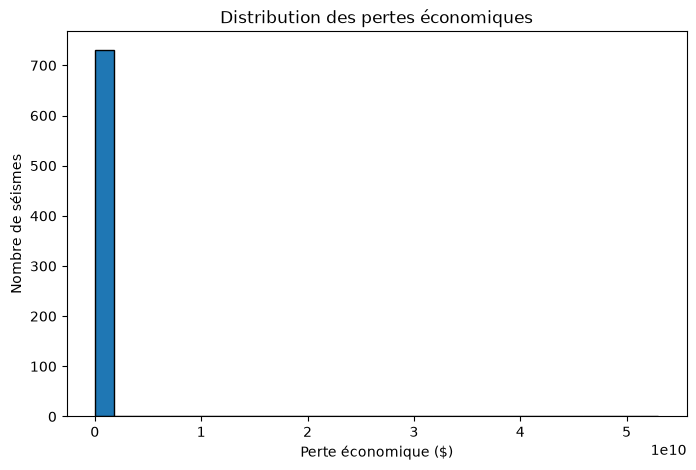

In [76]:
# Visualiser la distribution des pertes économiques

plt.figure(figsize=(8, 5))

plt.hist(y, bins=30, edgecolor='black')

plt.title("Distribution des pertes économiques")
plt.xlabel("Perte économique ($)")
plt.ylabel("Nombre de séismes")

plt.show()

**Interprétation du résultat :**

La distribution des pertes économiques est fortement asymétrique.

La majorité des séismes ont une perte économique nulle ou faible, tandis que quelques événements présentent des pertes extrêmement élevées.

Ces valeurs élevées étirent l'échelle du graphique et rendent les petites pertes difficiles à distinguer.

Une transformation logarithmique sera utile pour mieux représenter la variable cible et faciliter l'apprentissage des modèles.

## 39. Transformation logarithmique de la variable cible

Les pertes économiques présentent une très forte asymétrie.

J'applique une transformation logarithmique avec `log1p`, qui permet également de conserver les pertes égales à zéro.

Cette transformation réduit l'influence des valeurs extrêmement élevées et facilite l'apprentissage du modèle.

In [78]:
# Transformation logarithmique de la variable cible

y_log = np.log1p(y)

print("Y original :")
print(y.describe())

print("\nY après transformation logarithmique :")
print(y_log.describe())

Y original :
count    7.340000e+02
mean     9.758211e+07
std      1.996151e+09
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      5.299175e+10
Name: economic_loss, dtype: float64

Y après transformation logarithmique :
count    734.000000
mean       1.504756
std        4.375432
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       24.693402
Name: economic_loss, dtype: float64


**Interprétation du résultat :**

Avant la transformation, les pertes économiques varient de **0 $ à environ 53 milliards de dollars**, ce qui crée une très forte dispersion.

Après la transformation logarithmique, les valeurs sont comprises entre **0 et 24,69**.

La transformation réduit donc l'effet des pertes extrêmement élevées tout en conservant les événements dont la perte est égale à zéro.

La variable `y_log` sera utilisée pour entraîner les modèles de régression.

## 40. Séparation des données d'entraînement et de test

Je divise les données en deux ensembles.

**80 %** des données seront utilisées pour entraîner les modèles.

**20 %** seront conservées pour tester les modèles sur des données qu'ils n'ont pas utilisées pendant l'entraînement.

In [80]:
# Séparer les données en entraînement et test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_log,
    test_size=0.20,
    random_state=42
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (587, 6)
X_test  : (147, 6)
y_train : (587,)
y_test  : (147,)


**Interprétation du résultat :**

L'ensemble d'entraînement contient **587 observations**, soit environ **80 %** des données.

L'ensemble de test contient **147 observations**, soit environ **20 %** des données.

Le modèle sera entraîné avec `X_train` et `y_train`, puis évalué avec `X_test` et `y_test`.

## 41. Modèle 1 — Régression linéaire

Je commence avec une régression linéaire.

Ce modèle servira de modèle de référence afin de comparer ses performances avec celles des autres algorithmes de régression.

In [83]:
# Modèle 1 : Régression linéaire

from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

# Entraînement du modèle
linear_model.fit(X_train, y_train)

# Prédictions
y_pred_linear = linear_model.predict(X_test)

print("Modèle de régression linéaire entraîné avec succès.")

Modèle de régression linéaire entraîné avec succès.


**Interprétation du résultat :**

Le modèle de régression linéaire a été entraîné avec succès sur les **587 observations** de l'ensemble d'entraînement.

Il a ensuite généré des prédictions pour les **147 observations** de l'ensemble de test.

La prochaine étape consiste à mesurer ses performances à l'aide des métriques de régression.

## 42. Évaluation de la régression linéaire

J'évalue les performances du modèle de régression linéaire à l'aide de trois métriques : **MAE**, **RMSE** et **R²**.

Ces métriques permettent de mesurer l'erreur des prédictions et la capacité du modèle à expliquer les variations de la variable cible.

In [84]:
# Évaluer le modèle de régression linéaire

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("MAE  :", round(mae_linear, 4))
print("RMSE :", round(rmse_linear, 4))
print("R²   :", round(r2_linear, 4))

MAE  : 1.6604
RMSE : 3.0105
R²   : 0.5117


**Interprétation du résultat :**

La régression linéaire obtient un **R² de 0,5117**.

Cela signifie que le modèle explique environ **51 % de la variation** de la variable cible transformée.

La **MAE est de 1,6604** et la **RMSE de 3,0105** sur l'échelle logarithmique.

Ce premier modèle fournit une référence. Les prochains algorithmes permettront de vérifier si un modèle non linéaire peut obtenir de meilleures performances.

## 43. Modèle 2 — Random Forest

Je teste maintenant l'algorithme **Random Forest Regressor**.

Random Forest combine plusieurs arbres de décision et peut détecter des relations non linéaires entre les caractéristiques des séismes et les pertes économiques.

Les performances de ce modèle seront comparées à celles de la régression linéaire.

In [85]:
# Modèle 2 : Random Forest

from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Entraînement du modèle
random_forest_model.fit(X_train, y_train)

# Prédictions
y_pred_rf = random_forest_model.predict(X_test)

print("Modèle Random Forest entraîné avec succès.")

Modèle Random Forest entraîné avec succès.


**Interprétation du résultat :**

Le modèle **Random Forest** a été entraîné avec succès sur les données d'entraînement.

Il a ensuite généré des prédictions pour les observations de l'ensemble de test.

La prochaine étape consiste à calculer les mêmes métriques **MAE, RMSE et R²** afin de comparer ses performances avec celles de la régression linéaire.

## 44. Évaluation du modèle Random Forest

J'évalue maintenant le modèle Random Forest avec les mêmes métriques que la régression linéaire : **MAE**, **RMSE** et **R²**.

L'utilisation des mêmes métriques permettra de comparer directement les deux modèles.

In [86]:
# Évaluer le modèle Random Forest

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE  :", round(mae_rf, 4))
print("RMSE :", round(rmse_rf, 4))
print("R²   :", round(r2_rf, 4))

MAE  : 1.004
RMSE : 2.4327
R²   : 0.6812


**Interprétation du résultat :**

Le modèle **Random Forest** obtient un **R² de 0,6812**, ce qui signifie qu'il explique environ **68 % de la variation** de la variable cible transformée.

La **MAE est de 1,0040** et la **RMSE de 2,4327** sur l'échelle logarithmique.

Ces résultats sont meilleurs que ceux de la régression linéaire, qui avait obtenu un **R² de 0,5117**.

Random Forest est donc, pour le moment, le modèle le plus performant.

## 45. Modèle 3 — Gradient Boosting

Je teste maintenant l'algorithme **Gradient Boosting Regressor**.

Gradient Boosting construit plusieurs arbres de décision successivement. Chaque nouvel arbre cherche à corriger les erreurs produites par les arbres précédents.

Les résultats seront comparés à ceux de la régression linéaire et de Random Forest.

In [87]:
# Modèle 3 : Gradient Boosting

from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=200,
    random_state=42
)

# Entraînement du modèle
gradient_boosting_model.fit(X_train, y_train)

# Prédictions
y_pred_gb = gradient_boosting_model.predict(X_test)

print("Modèle Gradient Boosting entraîné avec succès.")

Modèle Gradient Boosting entraîné avec succès.


**Interprétation du résultat :**

Le modèle **Gradient Boosting** a été entraîné avec succès sur les données d'entraînement.

Il a ensuite généré des prédictions pour les **147 observations** de l'ensemble de test.

La prochaine étape consiste à calculer **MAE, RMSE et R²** afin de comparer ses performances aux deux modèles précédents.

## 46. Évaluation du modèle Gradient Boosting

J'évalue le modèle Gradient Boosting avec les mêmes métriques utilisées pour les modèles précédents : **MAE**, **RMSE** et **R²**.

Cette évaluation permettra de déterminer lequel des trois algorithmes offre les meilleures performances.

In [88]:
# Évaluer le modèle Gradient Boosting

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("MAE  :", round(mae_gb, 4))
print("RMSE :", round(rmse_gb, 4))
print("R²   :", round(r2_gb, 4))

MAE  : 1.0387
RMSE : 2.2755
R²   : 0.721


**Interprétation du résultat :**

Le modèle **Gradient Boosting** obtient un **R² de 0,7210**, ce qui signifie qu'il explique environ **72 % de la variation** de la variable cible transformée.

La **MAE est de 1,0387** et la **RMSE de 2,2755** sur l'échelle logarithmique.

Gradient Boosting obtient le meilleur **R²** et la plus faible **RMSE** parmi les trois modèles testés.

Random Forest conserve toutefois une MAE légèrement plus faible (**1,0040** contre **1,0387**).

Les trois modèles seront maintenant comparés dans un même tableau.

## 47. Comparaison des modèles

Je compare les performances des trois algorithmes de régression à l'aide des métriques **MAE**, **RMSE** et **R²**.

Cette comparaison permettra de sélectionner le modèle le plus performant pour la prédiction des pertes économiques.

In [89]:
# Comparer les performances des trois modèles

results = pd.DataFrame({
    'Modèle': [
        'Régression linéaire',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MAE': [
        mae_linear,
        mae_rf,
        mae_gb
    ],
    'RMSE': [
        rmse_linear,
        rmse_rf,
        rmse_gb
    ],
    'R²': [
        r2_linear,
        r2_rf,
        r2_gb
    ]
})

results = results.round(4)

results

,Modèle,MAE,RMSE,R²
0,Régression linéaire,1.6604,3.0105,0.5117
1,Random Forest,1.0040,2.4327,0.6812
2,Gradient Boosting,1.0387,2.2755,0.7210


**Interprétation du résultat :**

La **régression linéaire** obtient les performances les plus faibles avec un **R² de 0,5117**.

Le modèle **Random Forest** améliore les résultats avec un **R² de 0,6812** et obtient la plus faible **MAE (1,0040)**.

Le modèle **Gradient Boosting** obtient le meilleur **R² (0,7210)** et la plus faible **RMSE (2,2755)**.

Gradient Boosting explique donc environ **72 % de la variation de la variable cible transformée** et sera retenu comme meilleur modèle parmi les trois algorithmes testés.

## 48. Importance des variables

Je vérifie l'importance des variables utilisées par le modèle Gradient Boosting.

Cette analyse permet d'identifier les caractéristiques du séisme qui influencent le plus les prédictions du modèle.

In [ ]:
# Importance des variables du modèle Gradient Boosting

feature_importance = pd.DataFrame({
    'Variable': X.columns,
    'Importance': gradient_boosting_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

**Interprétation du résultat :**

La variable `sig` est la plus importante pour le modèle Gradient Boosting avec une importance d'environ **68,8 %**.

La magnitude (`mag`) arrive ensuite avec environ **12,1 %**, suivie de la longitude avec **10,4 %** et de la latitude avec **5,4 %**.

La profondeur contribue moins aux prédictions avec environ **2,9 %**.

La variable `tsunami` présente l'importance la plus faible avec environ **0,3 %**.

Selon ce modèle, l'indice d'importance USGS `sig` est donc la variable qui contribue le plus à la prédiction des pertes économiques estimées par PAGER.

## 49. Visualisation de l'importance des variables

Je représente graphiquement l'importance des variables du modèle Gradient Boosting.

Ce graphique permet de comparer plus facilement la contribution des différentes caractéristiques aux prédictions du modèle.

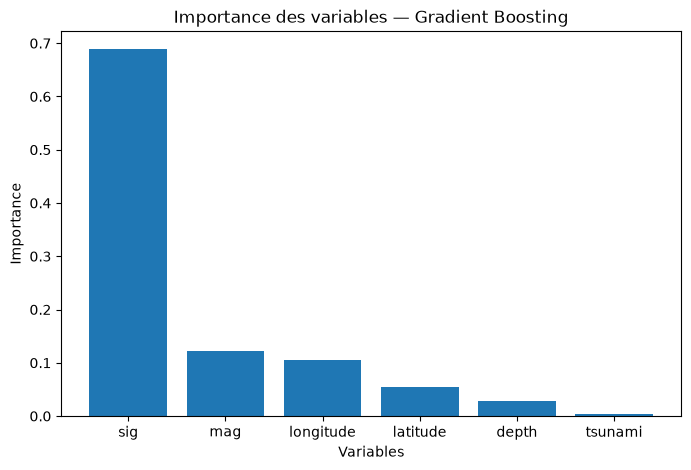

In [94]:
# Visualiser l'importance des variables

plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance['Variable'],
    feature_importance['Importance']
)

plt.title("Importance des variables — Gradient Boosting")
plt.xlabel("Variables")
plt.ylabel("Importance")

plt.show()

**Interprétation du résultat :**

Le graphique confirme que `sig` est la variable qui contribue le plus aux prédictions du modèle Gradient Boosting.

La magnitude et la longitude ont également une contribution visible, mais beaucoup plus faible.

La latitude et la profondeur ont une importance limitée, tandis que `tsunami` contribue très peu aux prédictions.

Ces résultats représentent l'importance des variables dans le modèle et ne signifient pas nécessairement qu'elles causent directement les pertes économiques.

## 50. Comparaison des valeurs réelles et prédites

Je compare les valeurs réelles de la variable cible avec les valeurs prédites par le modèle Gradient Boosting.

Comme le modèle a été entraîné sur une cible logarithmique, je reconvertis les valeurs vers l'échelle originale en dollars afin de faciliter l'interprétation des résultats.

In [95]:
# Reconvertir les valeurs logarithmiques en dollars

y_test_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(y_pred_gb)

# Les pertes économiques ne peuvent pas être négatives
y_pred_dollars = np.maximum(y_pred_dollars, 0)

comparison = pd.DataFrame({
    'Perte réelle ($)': y_test_dollars.values,
    'Perte prédite ($)': y_pred_dollars
})

comparison.head(10)

,Perte réelle ($),Perte prédite ($)
0,0.000000e+00,0.000000e+00
1,0.000000e+00,7.765810e-01
2,0.000000e+00,0.000000e+00
3,0.000000e+00,0.000000e+00
4,0.000000e+00,2.896916e-01
5,0.000000e+00,1.818878e+00
6,0.000000e+00,0.000000e+00
7,0.000000e+00,1.875282e-02
8,1.023897e+10,1.507536e+10
9,0.000000e+00,5.691026e-01


**Interprétation du résultat :**

Les prédictions ont été reconverties de l'échelle logarithmique vers l'échelle originale en dollars.

Pour plusieurs événements dont la perte PAGER est de **0 $**, le modèle prédit également une valeur nulle ou très faible.

Pour l'événement présentant une perte PAGER d'environ **10,24 milliards de dollars**, le modèle prédit environ **15,08 milliards de dollars**.

Le modèle parvient donc à détecter certains événements associés à des pertes économiques très importantes, mais les montants prédits peuvent présenter des écarts importants par rapport aux estimations PAGER.

## 51. Visualisation des valeurs réelles et prédites

Je représente les pertes économiques PAGER et les pertes prédites par le modèle Gradient Boosting.

Un modèle performant devrait produire des prédictions proches des valeurs PAGER correspondantes.

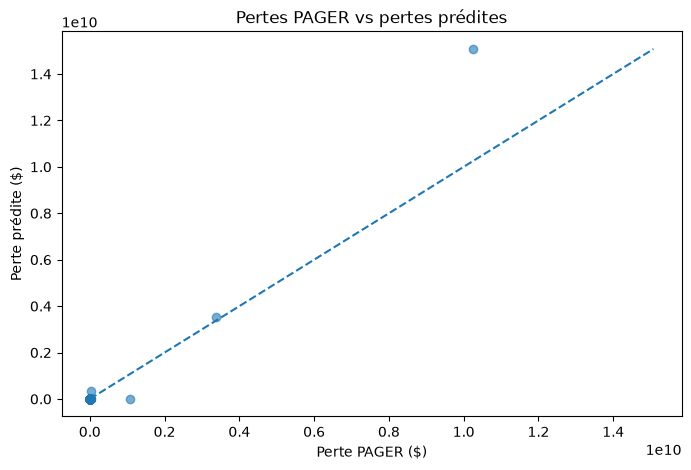

In [96]:
# Comparer les pertes PAGER et les pertes prédites

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test_dollars,
    y_pred_dollars,
    alpha=0.6
)

# Ligne idéale : prédiction = valeur PAGER
max_value = max(y_test_dollars.max(), y_pred_dollars.max())

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle='--'
)

plt.title("Pertes PAGER vs pertes prédites")
plt.xlabel("Perte PAGER ($)")
plt.ylabel("Perte prédite ($)")

plt.show()

**Interprétation du résultat :**

La ligne diagonale représente une prédiction parfaite, où la perte prédite serait exactement égale à la perte estimée par PAGER.

Plus un point est proche de cette ligne, plus la prédiction du modèle est précise.

Le graphique montre que le modèle reproduit assez bien certaines pertes importantes, mais que des écarts subsistent pour certains événements.

La forte concentration des observations près de zéro confirme également que la majorité des séismes du dataset ont une perte économique PAGER nulle ou faible.

## 52. Évaluation du modèle en dollars

Les métriques précédentes ont été calculées sur la variable cible transformée avec `log1p`.

Pour faciliter l'interprétation du modèle, je calcule maintenant les erreurs sur l'échelle originale des pertes économiques, en dollars.

Cette évaluation permettra de mesurer directement l'écart entre les estimations PAGER et les prédictions du modèle.

In [97]:
# Évaluer Gradient Boosting sur l'échelle originale en dollars

mae_dollars = mean_absolute_error(
    y_test_dollars,
    y_pred_dollars
)

rmse_dollars = np.sqrt(
    mean_squared_error(
        y_test_dollars,
        y_pred_dollars
    )
)

print("MAE en dollars  :", round(mae_dollars, 2), "$")
print("RMSE en dollars :", round(rmse_dollars, 2), "$")

MAE en dollars  : 44010119.16 $
RMSE en dollars : 409817278.89 $


**Interprétation du résultat :**

Sur l'échelle originale, le modèle Gradient Boosting obtient une **MAE d'environ 44,01 millions de dollars**.

Cela signifie que l'écart absolu moyen entre les estimations PAGER et les prédictions du modèle est d'environ **44 millions de dollars**.

La **RMSE est d'environ 409,82 millions de dollars**.

La RMSE est beaucoup plus élevée que la MAE parce que cette métrique pénalise davantage les erreurs importantes. Quelques séismes présentant des pertes de plusieurs milliards de dollars ont donc une forte influence sur cette valeur.

Pour cette raison, les métriques calculées sur l'échelle logarithmique restent importantes pour évaluer le modèle sur un dataset aussi asymétrique.

## 53. Sauvegarde du meilleur modèle

Le modèle Gradient Boosting a obtenu les meilleures performances globales parmi les trois algorithmes testés.

Je sauvegarde maintenant ce modèle afin de pouvoir le réutiliser ultérieurement pour effectuer de nouvelles prédictions sans avoir à refaire l'entraînement.

In [98]:
# Sauvegarder le meilleur modèle

model_path = "../models/economic_loss_gradient_boosting.pkl"

joblib.dump(
    gradient_boosting_model,
    model_path
)

print("Modèle sauvegardé avec succès.")
print("Emplacement :", model_path)

Modèle sauvegardé avec succès.
Emplacement : ../models/economic_loss_gradient_boosting.pkl


**Interprétation du résultat :**

Le meilleur modèle, **Gradient Boosting**, a été sauvegardé avec succès dans le dossier `models`.

Le fichier `economic_loss_gradient_boosting.pkl` contient le modèle entraîné.

Il pourra être chargé ultérieurement pour effectuer de nouvelles prédictions sans devoir réentraîner le modèle.

## 54. Vérification du modèle sauvegardé

Je recharge le modèle sauvegardé afin de vérifier que le fichier fonctionne correctement.

Cette étape confirme que le modèle peut être réutilisé pour effectuer de nouvelles prédictions sans refaire l'entraînement.

In [99]:
# Recharger le modèle sauvegardé

loaded_model = joblib.load(
    "../models/economic_loss_gradient_boosting.pkl"
)

# Faire une prédiction de test
test_prediction_log = loaded_model.predict(X_test.iloc[[0]])

# Revenir à l'échelle en dollars
test_prediction_dollars = np.expm1(test_prediction_log)

# Éviter une perte négative
test_prediction_dollars = np.maximum(test_prediction_dollars, 0)

print("Modèle chargé avec succès.")
print("Prédiction de test :", round(test_prediction_dollars[0], 2), "$")

Modèle chargé avec succès.
Prédiction de test : 0.0 $


**Interprétation du résultat :**

Le modèle sauvegardé a été rechargé avec succès.

Une prédiction de test a également été effectuée, ce qui confirme que le fichier `.pkl` est fonctionnel.

Pour cette observation, le modèle prédit une perte économique de **0 $**.

Le modèle est maintenant prêt à être réutilisé pour de nouvelles prédictions.

## 55. Conclusion

Dans ce notebook, j'ai développé un modèle de régression pour estimer les pertes économiques associées aux séismes.

Les caractéristiques des séismes proviennent du dataset USGS 2025 et la variable cible `economic_loss` provient des estimations économiques USGS PAGER.

Après le prétraitement, **734 événements** disposaient d'une estimation économique PAGER exploitable.

Trois algorithmes ont été entraînés et comparés : **Régression linéaire**, **Random Forest** et **Gradient Boosting**.

Le modèle **Gradient Boosting** a obtenu les meilleures performances globales avec un **R² de 0,7210** et une **RMSE de 2,2755** sur l'échelle logarithmique.

L'analyse de l'importance des variables montre que `sig` contribue le plus aux prédictions du modèle.

Le modèle final a été sauvegardé dans `economic_loss_gradient_boosting.pkl` et peut être réutilisé pour effectuer de nouvelles prédictions.

Les résultats doivent être interprétés comme une estimation des pertes économiques PAGER et non comme une mesure exacte des pertes économiques réellement observées après chaque séisme.

## 56. Prédiction pour un nouveau séisme

Je teste maintenant le modèle final avec les caractéristiques d'un nouveau séisme.

Les mêmes six variables utilisées pendant l'entraînement doivent être fournies au modèle : `mag`, `depth`, `sig`, `latitude`, `longitude` et `tsunami`.

La prédiction produite par le modèle sera ensuite reconvertie de l'échelle logarithmique vers une estimation en dollars.

In [100]:
# Exemple de nouveau séisme

new_earthquake = pd.DataFrame({
    'mag': [6.5],
    'depth': [20],
    'sig': [650],
    'latitude': [35.0],
    'longitude': [140.0],
    'tsunami': [0]
})

# Prédiction sur l'échelle logarithmique
prediction_log = loaded_model.predict(new_earthquake)

# Revenir à l'échelle en dollars
prediction_dollars = np.expm1(prediction_log)

# Éviter une valeur négative
prediction_dollars = np.maximum(prediction_dollars, 0)

print("Perte économique estimée :", round(prediction_dollars[0], 2), "$")

Perte économique estimée : 29.13 $


**Interprétation du résultat :**

Pour cet exemple, le modèle estime une perte économique d'environ **29,13 $**.

Cette valeur très faible montre une limite importante du modèle.

Le dataset d'entraînement contient **625 événements avec une perte PAGER égale à 0 $ sur 734 observations**. Le modèle a donc appris qu'une grande proportion des séismes sont associés à une perte économique nulle ou très faible.

De plus, les pertes économiques dépendent de facteurs qui ne sont pas directement présents dans les variables utilisées, notamment l'exposition de la population, les infrastructures et la vulnérabilité économique de la région.

Cette prédiction doit donc être considérée comme une estimation expérimentale du modèle et non comme une prévision économique réelle.

## 57. Limites du modèle

Le modèle présente plusieurs limites importantes.

La variable cible provient des **estimations USGS PAGER** et non des pertes économiques finales réellement observées.

De plus, seulement **734 événements** disposent d'une estimation économique exploitable et **625 d'entre eux ont une perte égale à 0 $**.

Les variables utilisées décrivent principalement les caractéristiques du séisme. Le modèle ne dispose pas directement d'informations détaillées sur la population exposée, la valeur des infrastructures, les bâtiments ou la vulnérabilité économique locale.

Les résultats doivent donc être considérés comme une expérimentation de modélisation des estimations PAGER et non comme un système permettant de prévoir exactement les dommages financiers d'un futur séisme.

## 58. Sauvegarde du dataset utilisé pour le modèle

Je sauvegarde le dataset final contenant les événements utilisés pour l'entraînement et l'évaluation du modèle.

Ce fichier permet de conserver les variables explicatives ainsi que la cible économique PAGER utilisée dans cette analyse.

In [102]:
# Sauvegarder le dataset final utilisé pour le modèle

final_dataset_path = "../data/economic_loss_model_2025.csv"

df_model.to_csv(
    final_dataset_path,
    index=False
)

print("Dataset final sauvegardé avec succès.")
print("Nombre d'observations :", len(df_model))
print("Emplacement :", final_dataset_path)

Dataset final sauvegardé avec succès.
Nombre d'observations : 734
Emplacement : ../data/economic_loss_model_2025.csv


**Interprétation du résultat :**

Le dataset final a été sauvegardé avec succès dans le dossier `data`.

Le fichier `economic_loss_model_2025.csv` contient les **734 événements** utilisés pour construire le modèle de prédiction des pertes économiques.

Ce fichier permet de conserver exactement les données utilisées pour l'entraînement et l'évaluation du modèle et facilite la reproductibilité du projet.